In [1]:
import gdown
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('/content/booking_hotel (1).xlsx')
df.head()

,Hotel Name,Location,Rating,Review Score,Number of,Room Score,Room Type,Bed Type,Room Price (in BDT or any other currency)
0,Krabi La Playa Resort - SHA Plus,Ao Nang Beach,8.2,Very Good,141,8.6,Deluxe Double or Twin Room,1 double or 2 twins,146026
1,KC Beach Club & Pool Villas,"Chaweng City Center , Chaweng",7.1,Good,193,NaN,Double Room with Balcony and Sea View,1 queen bed,215304
2,Rawai VIP Villas & Kids Park,Rawai Beach,8.3,Very Good,63,8.9,2 Bedroom Pool Villa,2 queen beds,435384
3,"FuramaXclusive Sathorn, Bangkok","Bang Rak, Bangkok",7.7,Good,"1,304",8.1,Executive Double Room,1 full bed,146240
4,Bo Phut Resort and Spa - SHA Plus,Bophut,9.3,Wonderful,294,9.6,Villa with Garden View,1 double or 2 twins,621072


In [3]:
# Kích thước dữ liệu
df.shape


(3465, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3465 entries, 0 to 3464
Data columns (total 9 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Hotel Name                                 3465 non-null   object 
 1   Location                                   3465 non-null   object 
 2   Rating                                     3365 non-null   object 
 3   Review Score                               3359 non-null   object 
 4   Number of                                  3359 non-null   object 
 5   Room    Score                              2709 non-null   float64
 6   Room Type                                  3465 non-null   object 
 7   Bed Type                                   3449 non-null   object 
 8   Room Price (in BDT or any other currency)  3465 non-null   int64  
dtypes: float64(1), int64(1), object(7)
memory usage: 243.8+ KB


In [5]:
df.columns = df.columns.str.strip()
df["Rating"] = pd.to_numeric(df["Rating"].astype(str).str.replace(",", ""), errors='coerce')
df["Number of"] = pd.to_numeric(df["Number of"].astype(str).str.replace(",", ""), errors='coerce')
df.head()

,Hotel Name,Location,Rating,Review Score,Number of,Room Score,Room Type,Bed Type,Room Price (in BDT or any other currency)
0,Krabi La Playa Resort - SHA Plus,Ao Nang Beach,8.2,Very Good,141.0,8.6,Deluxe Double or Twin Room,1 double or 2 twins,146026
1,KC Beach Club & Pool Villas,"Chaweng City Center , Chaweng",7.1,Good,193.0,NaN,Double Room with Balcony and Sea View,1 queen bed,215304
2,Rawai VIP Villas & Kids Park,Rawai Beach,8.3,Very Good,63.0,8.9,2 Bedroom Pool Villa,2 queen beds,435384
3,"FuramaXclusive Sathorn, Bangkok","Bang Rak, Bangkok",7.7,Good,1304.0,8.1,Executive Double Room,1 full bed,146240
4,Bo Phut Resort and Spa - SHA Plus,Bophut,9.3,Wonderful,294.0,9.6,Villa with Garden View,1 double or 2 twins,621072


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3465 entries, 0 to 3464
Data columns (total 9 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Hotel Name                                 3465 non-null   object 
 1   Location                                   3465 non-null   object 
 2   Rating                                     3359 non-null   float64
 3   Review Score                               3359 non-null   object 
 4   Number of                                  3328 non-null   float64
 5   Room    Score                              2709 non-null   float64
 6   Room Type                                  3465 non-null   object 
 7   Bed Type                                   3449 non-null   object 
 8   Room Price (in BDT or any other currency)  3465 non-null   int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 243.8+ KB


In [7]:
df.describe()

,Rating,Number of,Room Score,Room Price (in BDT or any other currency)
count,3359.000000,3328.000000,2709.000000,3.465000e+03
mean,8.205389,1046.850361,8.779734,3.437072e+05
std,0.808736,1362.785639,0.472312,7.488245e+05
min,1.000000,2.000000,8.000000,2.588000e+03
25%,7.900000,183.000000,8.400000,1.504710e+05
50%,8.300000,556.000000,8.800000,2.266210e+05
75%,8.700000,1422.000000,9.100000,3.558920e+05
max,10.000000,13504.000000,10.000000,2.436536e+07


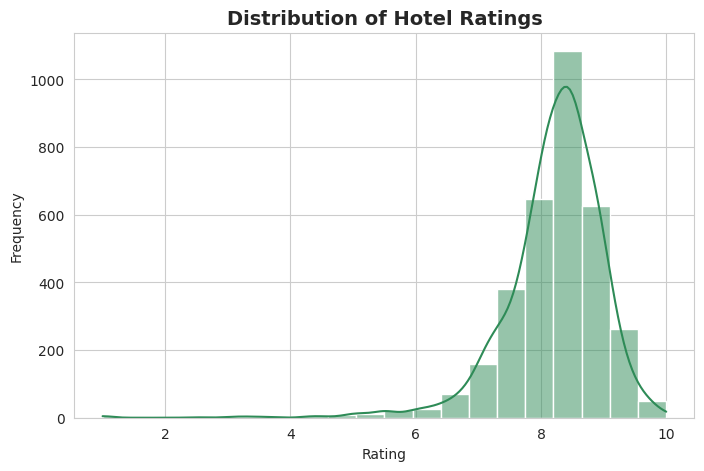

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(8,5))

sns.histplot(df["Rating"].dropna(),
             bins=20,
             color="#2E8B57",
             edgecolor="white",
             kde=True)

plt.title("Distribution of Hotel Ratings", fontsize=14, fontweight="bold")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

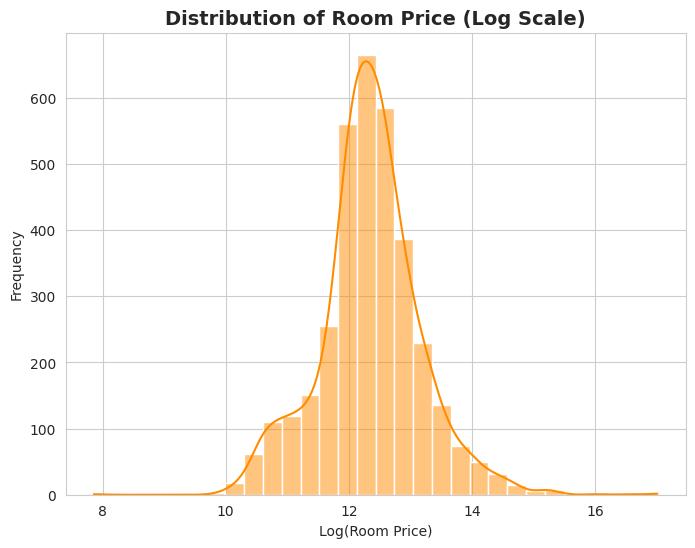

In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Lấy log của giá phòng
log_price = np.log(df["Room Price (in BDT or any other currency)"])

plt.figure(figsize=(8,6))
sns.histplot(log_price, bins=30, kde=True, color="#FF8C00")

plt.title("Distribution of Room Price (Log Scale)", fontsize=14, fontweight="bold")
plt.xlabel("Log(Room Price)")
plt.ylabel("Frequency")

plt.show()

2.1 Tạo biến mục tiêu Sactifaction

In [10]:
# Chuẩn hóa chữ cho Review Score
df["Review Score"] = df["Review Score"].str.strip()

# Tạo biến Satisfaction
df["Satisfaction"] = df["Review Score"].apply(
    lambda x: 1 if x in ["Very Good", "Excellent", "Wonderful"] else 0
)

df[["Review Score", "Satisfaction"]].head()


,Review Score,Satisfaction
0,Very Good,1
1,Good,0
2,Very Good,1
3,Good,0
4,Wonderful,1


In [11]:
# Phân bố biến mục tiêu
df["Satisfaction"].value_counts()


,count
Satisfaction,
1,2325
0,1140


/tmp/ipykernel_299/3464093984.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


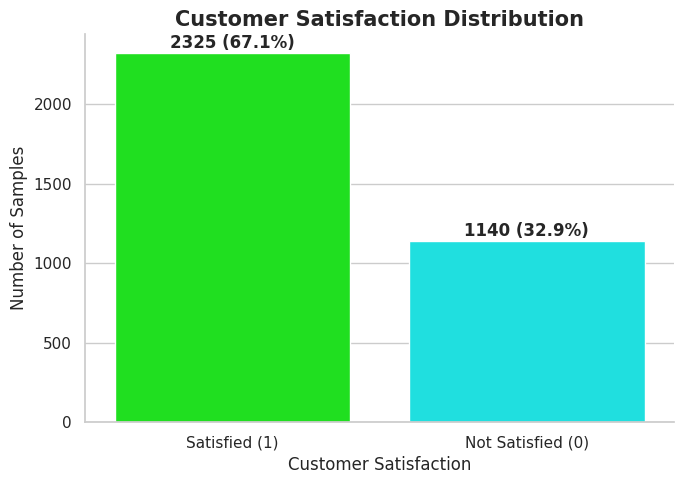

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

counts = df["Satisfaction"].value_counts()

plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=["Satisfied (1)", "Not Satisfied (0)"],
    y=counts.values,
    palette=["#00FF00", "#00FFFF"]
)

total = counts.sum()

for i, v in enumerate(counts.values):
    percent = v / total * 100
    ax.text(i, v + 30,
            f"{v} ({percent:.1f}%)",
            ha="center",
            fontsize=12,
            fontweight="bold")

plt.title("Customer Satisfaction Distribution", fontsize=15, fontweight="bold")
plt.xlabel("Customer Satisfaction")
plt.ylabel("Number of Samples")

sns.despine()
plt.tight_layout()

plt.show()

3.1. Xử lý dữ liệu bị thiếu

In [13]:
# Kiểm tra dữ liệu thiếu
df.isnull().sum()


,0
Hotel Name,0
Location,0
Rating,106
Review Score,106
Number of,137
Room Score,756
Room Type,0
Bed Type,16
Room Price (in BDT or any other currency),0
Satisfaction,0


In [14]:
# Xử lý dữ liệu thiếu cho cột số
for col in df.select_dtypes(include="number").columns:
    df[col] = df[col].fillna(df[col].median())

# Xử lý dữ liệu thiếu cho cột object
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [15]:
#Kiểm tra dữ liệu bị thiếu sau khi xử lý
df.isnull().sum()

,0
Hotel Name,0
Location,0
Rating,0
Review Score,0
Number of,0
Room Score,0
Room Type,0
Bed Type,0
Room Price (in BDT or any other currency),0
Satisfaction,0


In [16]:
# Các cột không dùng cho mô hình
unused_cols = ["Hotel Name", "Review Score"]
df.drop(columns=[col for col in unused_cols if col in df.columns], inplace=True)


In [17]:
# Chọn biến đầu vào và loại bỏ biến không cần thiết
features = [
    "Rating",
    "Number of",
    "Room Price (in BDT or any other currency)",
    "Room Type",
    "Bed Type",
    "Location"
]

X = df[features]
y = df["Satisfaction"]


In [18]:
# Mã hóa biến phân loại & chuẩn hóa biến số
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer


In [19]:
numeric_features = [
    "Rating",
    "Number of",
    "Room Price (in BDT or any other currency)"
]

categorical_features = [
    "Room Type",
    "Bed Type",
    "Location"
]

In [20]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


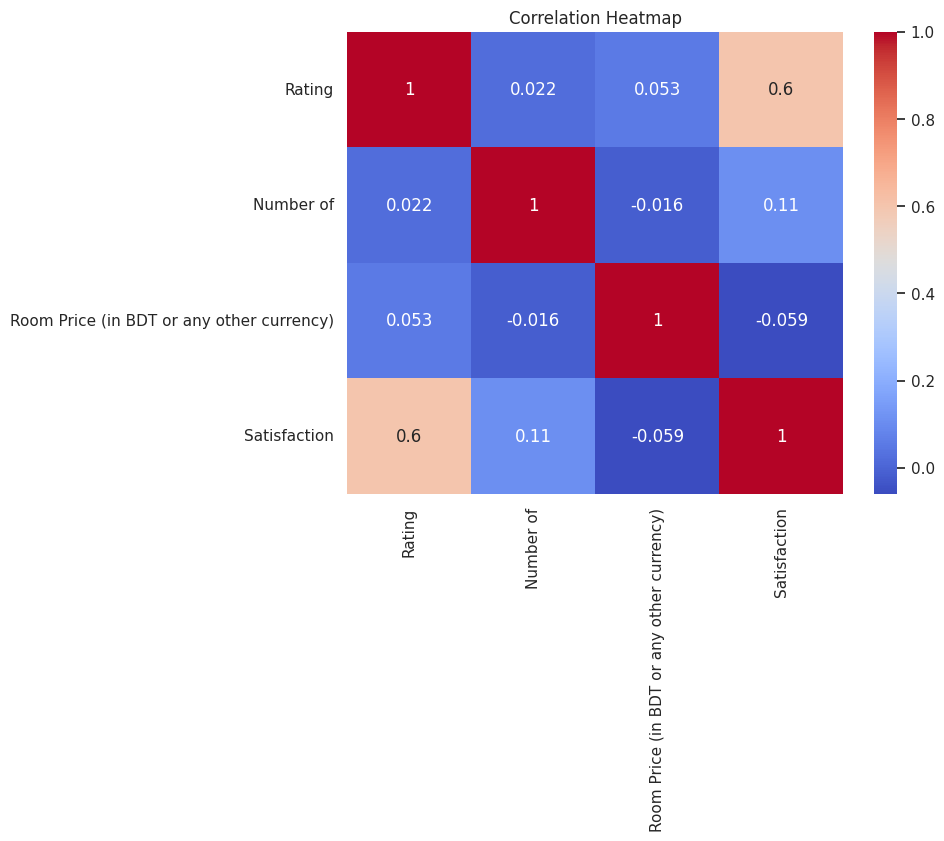

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(
    df[numeric_features + ["Satisfaction"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

In [22]:
# Chia tập dữ liệu train-test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


**Logistic Regression**

In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


In [25]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

logistic_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Rating', 'Number of',
                                                   'Room Price (in BDT or any '
                                                   'other currency)']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Room Type', 'Bed Type',
                                                   'Location'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

SVM

In [26]:
from sklearn.svm import SVC


In [27]:
from sklearn.model_selection import GridSearchCV

svm_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", SVC(probability=True))
    ]
)

param_grid = {
    "classifier__C": [0.1, 1, 10],
    "classifier__gamma": ["scale", 0.1, 0.01],
    "classifier__kernel": ["rbf"]
}

grid = GridSearchCV(
    svm_model,
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

best_svm = grid.best_estimator_

In [28]:
print("Best parameters:", grid.best_params_)

Best parameters: {'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}


PHẦN 5: KẾT QUẢ VÀ ĐÁNH GIÁ

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Tạo pipeline cho mô hình Logistic Regression
logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])

# Huấn luyện mô hình
logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

print("Accuracy (Logistic):", accuracy_score(y_test, y_pred_logistic))
print(classification_report(y_test, y_pred_logistic))

Accuracy (Logistic): 0.925
              precision    recall  f1-score   support

           0       0.93      0.83      0.88       342
           1       0.92      0.97      0.95       698

    accuracy                           0.93      1040
   macro avg       0.93      0.90      0.91      1040
weighted avg       0.93      0.93      0.92      1040



In [30]:
confusion_matrix(y_test, y_pred_logistic)


array([[284,  58],
       [ 20, 678]])

In [31]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

# Tạo pipeline cho mô hình SVM
svm_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42))
])

# Huấn luyện mô hình
svm_model.fit(X_train, y_train)

y_pred_svm = best_svm.predict(X_test)

print("Accuracy (SVM):", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy (SVM): 0.9567307692307693
              precision    recall  f1-score   support

           0       0.97      0.90      0.93       342
           1       0.95      0.99      0.97       698

    accuracy                           0.96      1040
   macro avg       0.96      0.94      0.95      1040
weighted avg       0.96      0.96      0.96      1040



In [32]:
confusion_matrix(y_test, y_pred_svm)


array([[307,  35],
       [ 10, 688]])

In [33]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_svm)
    ]
})

results


,Model,Accuracy
0,Logistic Regression,0.925000
1,SVM,0.956731


Lập bảng so sánh 2 mô hình

In [34]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss
)


In [35]:
# Logistic Regression
y_pred_log = logistic_model.predict(X_test)
y_prob_log = logistic_model.predict_proba(X_test)

# SVM

y_pred_svm = best_svm.predict(X_test)

In [36]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM"],

    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_svm)
    ],

    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_svm)
    ],

    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_svm)
    ],

    "F1-score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_svm)
    ],

    "Loss Function": [
        log_loss(y_test, y_prob_log),   # Log-loss cho Logistic
        None                            # SVM không dùng loss này
    ]
})


In [37]:
comparison_df


,Model,Accuracy,Precision,Recall,F1-score,Loss Function
0,Logistic Regression,0.925000,0.921196,0.971347,0.945607,0.305902
1,SVM,0.956731,0.951591,0.985673,0.968332,NaN


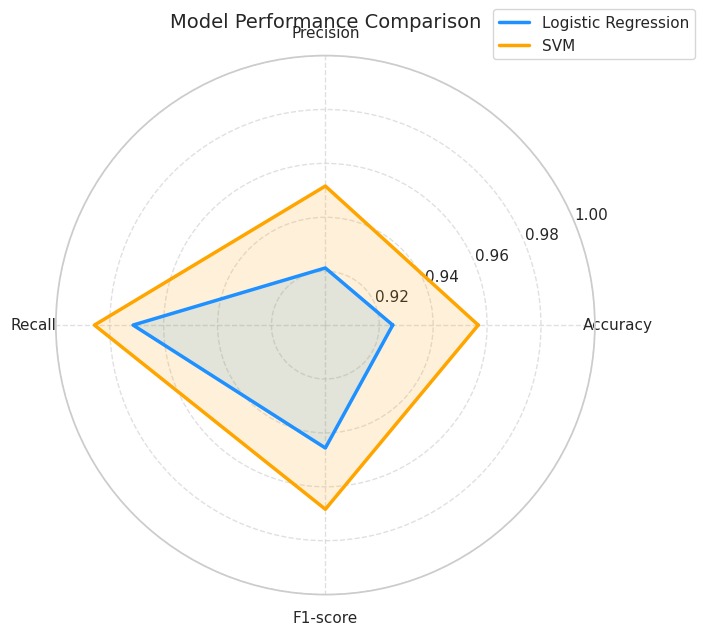

In [38]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

logistic_scores = [0.925000, 0.921196, 0.971347, 0.945607]
svm_scores = [0.956731, 0.951591, 0.985673, 0.968332]

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False)
angles = np.concatenate((angles, [angles[0]]))

logistic_scores = logistic_scores + [logistic_scores[0]]
svm_scores = svm_scores + [svm_scores[0]]

plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)

ax.plot(angles, logistic_scores, linewidth=2.5, color="dodgerblue", label="Logistic Regression")
ax.fill(angles, logistic_scores, color="dodgerblue", alpha=0.15)

ax.plot(angles, svm_scores, linewidth=2.5, color="orange", label="SVM")
ax.fill(angles, svm_scores, color="orange", alpha=0.15)

# Labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=11)

# Zoom thang đo để dễ nhìn
ax.set_ylim(0.9, 1.0)

# Grid đẹp hơn
ax.grid(True, linestyle="--", alpha=0.6)

plt.title("Model Performance Comparison", size=14, pad=20)
plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))

plt.show()

<Figure size 600x500 with 0 Axes>

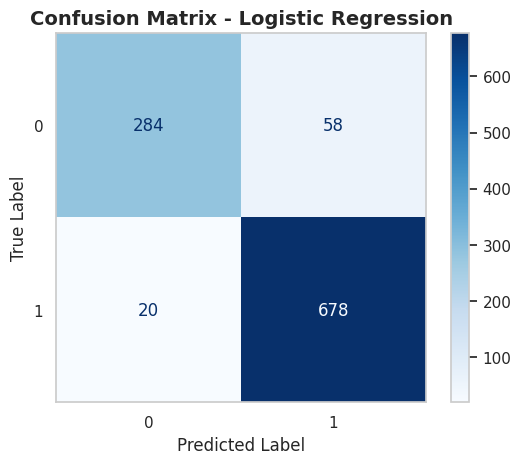

<Figure size 600x500 with 0 Axes>

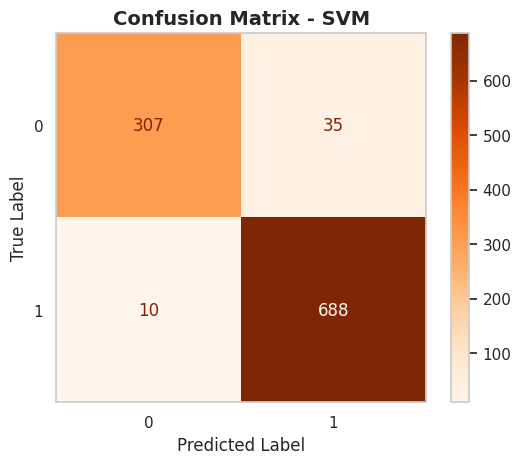

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp_log.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix - Logistic Regression", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.grid(False)
plt.show()


# SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp_svm.plot(cmap="Oranges", values_format='d')
plt.title("Confusion Matrix - SVM", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.grid(False)
plt.show()

In [40]:
# Dự báo nhãn (0 / 1)
y_pred_svm = best_svm.predict(X_test)

# Xem thử 10 kết quả đầu
prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_svm
})
prediction_df["Result"] = np.where(
    prediction_df["Actual"] == prediction_df["Predicted"],
    "Correct",
    "Incorrect" )
prediction_df.head(10)


,Actual,Predicted,Result
0,1,1,Correct
1,1,1,Correct
2,1,1,Correct
3,1,1,Correct
4,0,0,Correct
5,1,1,Correct
6,0,0,Correct
7,1,1,Correct
8,0,0,Correct
9,1,1,Correct


In [41]:
result_count = prediction_df["Result"].value_counts()
print(result_count)

Result
Correct      995
Incorrect     45
Name: count, dtype: int64


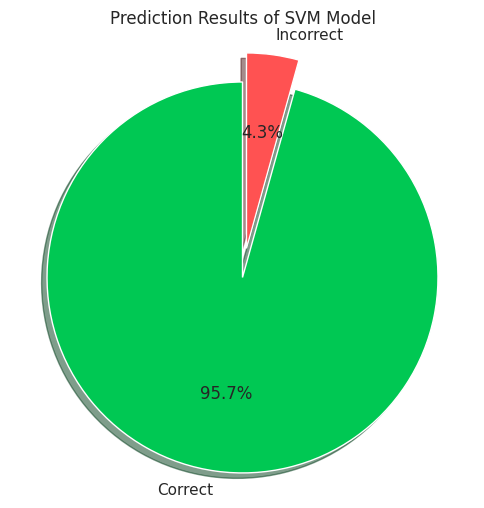

In [42]:
import matplotlib.pyplot as plt

labels = ["Correct", "Incorrect"]
values = [995, 45]

colors = ["#00C853", "#FF5252"]

plt.figure(figsize=(6,6))

plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    explode=(0.05, 0.1),
    shadow=True
)

plt.title("Prediction Results of SVM Model")
plt.axis("equal")

plt.show()

BÀI TOÁN GIẢI ĐỊNH ĐỂ DỰ BÁO, VÀ CHỨNG MINH MÔ HÌNH

In [43]:
# Ví dụ một khách du lịch mới
new_customer = pd.DataFrame({
    "Rating": [8],
    "Number of": [320],
    "Room Price (in BDT or any other currency)": [80000],
    "Room Type": ["Deluxe Double Room"],
    "Bed Type": ["1 double bed"],
    "Location": ["Phuket"]
})

# Dự đoán mức độ hài lòng
prediction = best_svm.predict(new_customer)
if prediction[0] == 1:
    print("Dự đoán: Khách hàng HÀI LÒNG")
else:
    print("Dự đoán: Khách hàng KHÔNG HÀI LÒNG")

prob = best_svm.predict_proba(new_customer)
print('Probability of satisfaction:', prob)

Dự đoán: Khách hàng HÀI LÒNG
Probability of satisfaction: [[0.18829466 0.81170534]]
